# Import

|CD | Fibre | Sweep | ID | 
|---|---|---|---|
|5 | White | None | N/A | 
|6 | Beige | Warming | 69 | 
|7 | BF | Cooling | 5 | 
|7 | BF | Warming | 9 | 
|8 | BF Unclamped | Cooling | 9 | 

5: ID7-9 is RT measurements and 10-12 is 4K measurement 


In [2]:
import time
from time import sleep, monotonic
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import pyvisa
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
from qcodes.station import Station
from functions import quick_check
from functions import calibrate
import snspd
import scipy
import scipy.constants as spc

Logging hadn't been started.
Activating auto-logging. Current session state plus future input saved.
Filename       : C:\Users\QNL\.qcodes\logs\command_history.log
Mode           : append
Output logging : True
Raw input log  : False
Timestamping   : True
State          : active
Qcodes Logfile : C:\Users\QNL\.qcodes\logs\260505-29692-qcodes.log


In [7]:
config_combined = 'D:\SNSPD\SNSPD2\SNSPD5\snspd5-8_combined.yaml'
params = snspd.snspd(config_combined)

db4 = "./2026-03-10_SNSPD4.db"
exname4 = 'SNSPD4_23_03_2026'
sampname4 = '00'

db5 = "./2026-04-17_SNSPD5.db"
exname5 = 'SNSPD5'
sampname5 = '00'

db6 = "./2026-04-17_SNSPD6.db"
exname6 = 'SNSPD6'
sampname6 = '00'

db7 = "./2026-04-17_SNSPD7.db"
exname7 = 'SNSPD7'
sampname7 = '00'

db8 = "./2026-04-17_SNSPD8.db"
exname8 = 'SNSPD8'
sampname8 = '00'

db9 = "./2026-04-17_SNSPD9.db"
exname9 = 'SNSPD9'
sampname9 = '00'

db10 = "./2026-04-17_SNSPD10.db"
exname10 = 'SNSPD10'
sampname10 = '00'


2026-05-05 23:57:41,593 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ <>:1: SyntaxWarning: invalid escape sequence '\S'

2026-05-05 23:57:41,594 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ <>:1: SyntaxWarning: invalid escape sequence '\S'

2026-05-05 23:57:41,596 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\AppData\Local\Temp\ipykernel_29692\651843798.py:1: SyntaxWarning: invalid escape sequence '\S'
  config_combined = 'D:\SNSPD\SNSPD2\SNSPD5\snspd5-8_combined.yaml'



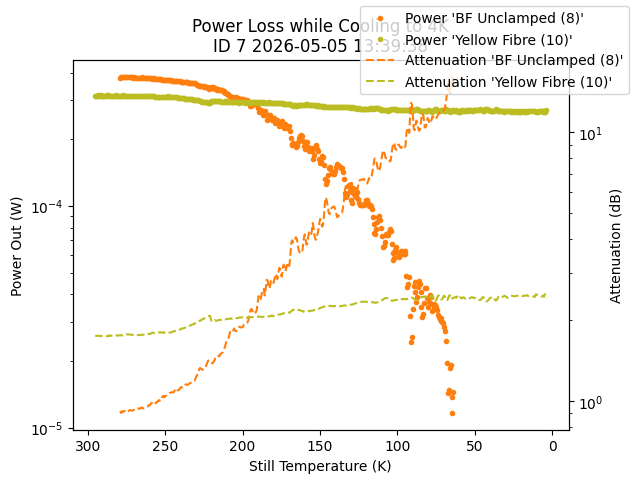

In [13]:

ID = 9
data_8 = params.load_id_from_database(db8, exname8, sampname8, ID).get_parameter_data()
power10_8 = data_8['power10']['power10']
power90_8 = data_8['power90']['power90']
attenuation_8 = data_8['attenuation']['attenuation']
still_temp_8 = data_8['still_temp']['still_temp']

ID = 5
data_9 = params.load_id_from_database(db9, exname9, sampname9, ID).get_parameter_data()
power10_9 = data_9['power10']['power10']
power90_9 = data_9['power90']['power90']
attenuation_9 = data_9['attenuation']['attenuation']
still_temp_9 = data_9['still_temp']['still_temp']

ID = 7
data_10 = params.load_id_from_database(db10, exname10, sampname10, ID).get_parameter_data()
power10_10 = data_10['power10']['power10']
power90_10 = data_10['power90']['power90']
attenuation_10 = data_10['attenuation']['attenuation']
still_temp_10 = data_10['still_temp']['still_temp']

fig, ax1 = plt.subplots()

ax1.semilogy(still_temp_8, power10_8, '.', color = 'tab:orange', label='Power \'BF Unclamped (8)\'')
ax1.set_xlabel('Still Temperature (K)')
ax1.set_ylabel('Power Out (W)')
ax1.set_title(params.make_title('Power Loss while Cooling to 4K', ID))
ax1.invert_xaxis()

ax2 = ax1.twinx()
ax2.semilogy(still_temp_8, attenuation_8, '--', color='tab:orange', label='Attenuation \'BF Unclamped (8)\'') 
ax2.set_xlabel('Still Temperature (K)')
ax2.set_ylabel('Attenuation (dB)')

ax1.semilogy(still_temp_10, power10_10, '.', color = 'tab:olive', label='Power \'Yellow Fibre (10)\'')
ax1.set_xlabel('Still Temperature (K)')
ax1.set_ylabel('Power Out (W)')

ax2.semilogy(still_temp_10, attenuation_10, '--', color='tab:olive', label='Attenuation \'Yellow Fibre (10)\'') 
ax2.set_xlabel('Still Temperature (K)')
ax2.set_ylabel('Attenuation (dB)')

fig.legend()

